# Training Model CRNN dengan PyTorch (Setara Branch Main)

Notebook ini mengadopsi arsitektur `Bidirectional LSTM` dengan *Temporal Average Pooling* milik *branch* `main` yang terbukti mencapai akurasi sangat tinggi (99%).

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import os

print('Library PyTorch Siap!')

Library PyTorch Siap!


In [8]:
# 1. Load Data (Fitur 64-Mels yang diekstrak sebelumnya)
X = np.load('X_features_2d_preprocessed.npy')
y = np.load('y_labels_preprocessed.npy')

# PyTorch mengharapkan format (Batch, Channels, Height, Width)
# Data kita: (Batch, Freq/Mels, Time)
# Ubah menjadi (Batch, 1, Mels, Time)
X = X[:, np.newaxis, :, :]

# # 2. Augmentasi Noise Sederhana (Opsional, untuk melipatgandakan data latih)
# noise = np.random.normal(0, 0.015, X.shape)
# X_aug = X + noise

# # Gabungkan asli + aug
# X_combined = np.vstack((X, X_aug))
# y_combined = np.hstack((y, y))

print(f"Total data: {X.shape}")

# 3. Stratified Split 80:20
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in sss.split(X, y):
    X_train_np, X_val_np = X[train_idx], X[val_idx]
    y_train_np, y_val_np = y[train_idx], y[val_idx]

# 4. Konversi ke PyTorch Tensor
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(y_val_np, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Bentuk Data Latih: {X_train.shape}")
print(f"Bentuk Data Uji:   {X_val.shape}")

Total data: (630, 1, 64, 150)
Bentuk Data Latih: torch.Size([504, 1, 64, 150])
Bentuk Data Uji:   torch.Size([126, 1, 64, 150])


In [9]:
class GreetingCRNN(nn.Module):
    def __init__(self, num_classes=7):
        super(GreetingCRNN, self).__init__()
        
        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Pooling freq, biarkan waktu utuh
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),
        )
        
        # Setelah 2x MaxPool pada 64 mels -> tersisa 16 bins.
        # 64 channels * 16 bins = 1024 features per rentang waktu.
        self.lstm = nn.LSTM(input_size=1024, hidden_size=128, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch, 1, 64 mels, time_steps)
        x = self.conv(x)
        
        # x shape: (batch, 64 channels, 16 bins, time_steps)
        batch, channels, h_out, w_out = x.size()
        
        # Reshape ke (batch, time_steps, channels * h_out)
        x = x.permute(0, 3, 2, 1).contiguous()
        x = x.view(batch, w_out, -1)
        
        # LSTM
        lstm_out, _ = self.lstm(x)
        
        # TEMPORAL AVERAGE POOLING (Merata-ratakan seluruh rentang waktu)
        x = torch.mean(lstm_out, dim=1)
        
        x = self.fc(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GreetingCRNN().to(device)
print(model)

GreetingCRNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(1024, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50
best_val_acc = 0.0

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
os.makedirs('models', exist_ok=True)

print("Memulai Training PyTorch...")
for epoch in range(EPOCHS):
    # --- TRAINING ---
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    epoch_train_loss = train_loss / total
    epoch_train_acc = correct / total
    
    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
    epoch_val_loss = val_loss / total
    epoch_val_acc = correct / total
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'models/CRNN_best.pth')
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

print("Training Selesai!")
print(f"Akurasi Validasi Terbaik: {best_val_acc * 100:.2f}%")

Memulai Training PyTorch...
Epoch [1/50] | Train Loss: 1.9362 Acc: 0.1508 | Val Loss: 1.9142 Acc: 0.1984
Epoch [5/50] | Train Loss: 1.3477 Acc: 0.4484 | Val Loss: 1.3059 Acc: 0.4762
Epoch [10/50] | Train Loss: 0.6912 Acc: 0.7341 | Val Loss: 0.9868 Acc: 0.6349
Epoch [15/50] | Train Loss: 0.4313 Acc: 0.8492 | Val Loss: 0.7107 Acc: 0.7698
Epoch [20/50] | Train Loss: 0.2562 Acc: 0.9306 | Val Loss: 0.8041 Acc: 0.7698
Epoch [25/50] | Train Loss: 0.1400 Acc: 0.9583 | Val Loss: 0.5963 Acc: 0.8651
Epoch [30/50] | Train Loss: 0.0675 Acc: 0.9821 | Val Loss: 0.5004 Acc: 0.9127
Epoch [35/50] | Train Loss: 0.0047 Acc: 1.0000 | Val Loss: 0.6175 Acc: 0.8810
Epoch [40/50] | Train Loss: 0.0026 Acc: 1.0000 | Val Loss: 0.6946 Acc: 0.8889
Epoch [45/50] | Train Loss: 0.2579 Acc: 0.9206 | Val Loss: 0.4381 Acc: 0.8810
Epoch [50/50] | Train Loss: 0.0905 Acc: 0.9702 | Val Loss: 0.3704 Acc: 0.9127
Training Selesai!
Akurasi Validasi Terbaik: 91.27%



Classification Report:
              precision    recall  f1-score   support

       horas       1.00      1.00      1.00        18
  sampurasun       1.00      1.00      1.00        18
adilkatalino       1.00      1.00      1.00        18
      wawawa       1.00      1.00      1.00        18
   kulanuwun       1.00      1.00      1.00        18
       tabea       1.00      1.00      1.00        18
     peuhaba       1.00      1.00      1.00        18

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



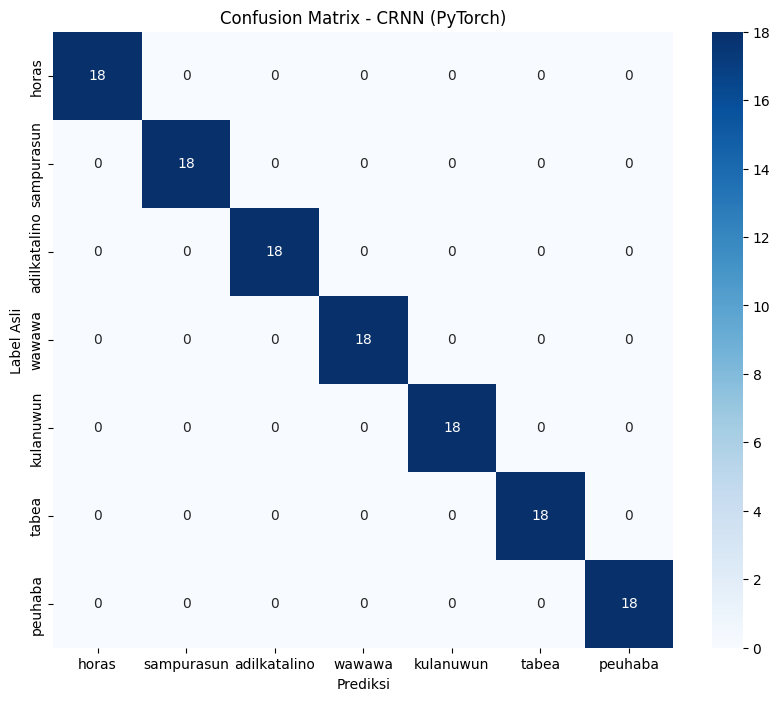

In [11]:
# Load model terbaik
model.load_state_dict(torch.load('models/best_model_CRNN.pth'))
model.eval()

all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=classes))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - CRNN (PyTorch)')
plt.ylabel('Label Asli')
plt.xlabel('Prediksi')
plt.show()

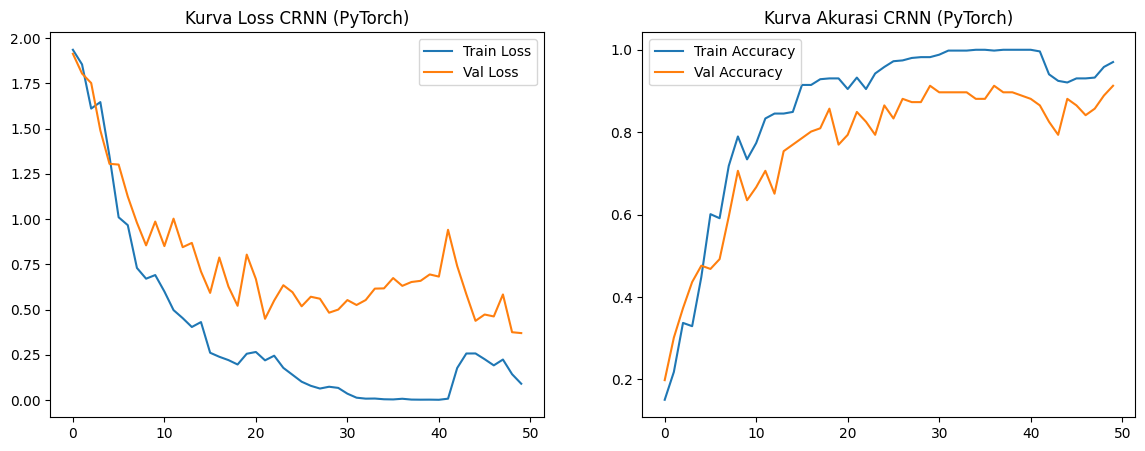

In [12]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Kurva Loss CRNN (PyTorch)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Kurva Akurasi CRNN (PyTorch)')
plt.legend()
plt.show()